In [1]:
using VeryDiff, LinearAlgebra, Plots 
using VeryDiff: LayeredModel, to_layered_model, ONNXChebyshevPoly
import VeryDiff: approximate_polynomial_iterative, approximate_polynomial_iterative_sampling, approximate_polynomial_abcrown

using VNNLib
const OXP = VNNLib.OnnxParser

using VeryDiffPolyExperiments
using VeryDiffPolyExperiments: generate_poly_network, convert_to_list_of_tuples, merge_normalization_into_dense

Set parameter Username
Set parameter LicenseID to value 2751365
Academic license - for non-commercial use only - expires 2026-12-08


**TODO**:
- make abcrown work with not only `[0,1]` bounds!

In [2]:
using VeryDiffPolyExperiments: load_mnist_data, acc_fun, max_fun, mae_fun, mse_fun, evaluate_network

VeryDiff.ALMOST_ZERO_LEADING_COEFF_WARNING[] = false

false

In [3]:
X_test, y_labels = load_mnist_data()
y_labels = y_labels .+ 1;  # convert to 1-based indexing

In [4]:
function compute_approximation_stats(onnx_path, degrees; max_polys_per_layer=1, max_iter=0, verbosity=0, mode=:zono)
    onnx_model = load_onnx_model(onnx_path)
    nn = to_layered_model(onnx_model)

    ŷ = [nn(x) for x in X_test]
    ŷ = hcat(ŷ...)'
    original_acc = acc_fun(y_labels, ŷ)
    println("Original accuracy: $original_acc")

    max_errs_single = []
    maes_single = []
    mses_single = []
    accs_single = []

    for d in degrees
        if mode == :zono
            nn_poly = approximate_polynomial_iterative_sampling(nn, X_test, d, max_polys_per_layer=max_polys_per_layer, verbosity=verbosity, max_iter=max_iter)
        elseif mode == :abcrown 
            nn_poly = approximate_polynomial_abcrown(onnx_path, d, max_polys_per_layer=max_polys_per_layer, max_iter=max_iter, verbosity=verbosity);
        else
            nn_poly = approximate_polynomial_iterative(nn, Zonotope(zeros(784), ones(784)), d, max_polys_per_layer=max_polys_per_layer, verbosity=verbosity, max_iter=max_iter)
        end
        max_err, mae, mse, acc, _ = evaluate_network(nn_poly, X_test, ŷ, y_labels, max_fun, mae_fun, mse_fun, acc_fun)
        push!(max_errs_single, max_err)
        push!(maes_single, mae)
        push!(mses_single, mse)
        push!(accs_single, acc)
        println("Degree $d: max err = $max_err, mae = $mae, mse = $mse, acc = $acc")
    end

    return max_errs_single, maes_single, mses_single, accs_single
end

compute_approximation_stats (generic function with 1 method)

# MNIST

## MNIST 1e-4

In [ ]:
degrees = 1:15
max_polys_per_layer = Inf
max_iter=20

result_dict = Dict();

### GeLU

In [ ]:
onnx_path = "../networks/mnist/mnist_gelu_256x4_1e4.onnx"

In [6]:
mode = :abcrown
max_errs, maes, mses, accs = compute_approximation_stats(onnx_path, degrees; max_polys_per_layer=max_polys_per_layer, max_iter=max_iter, mode=mode)
result_dict["gelu_1e4_abcrown"] = (max_errs=max_errs, maes=maes, mses=mses, accs=accs)

┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Original accuracy: 0.9893


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Degree 1: max err = 85.61560201589566, mae = 70.4568109519362, mse = 19672.101582907748, acc = 0.10441666666666667
Degree 2: max err = 25.029373515053717, mae = 14.154413687154873, mse = 405.27365994868825, acc = 0.3993833333333333


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


...

Degree 14: max err = 4.1340602218449645, mae = 2.0569959125831483, mse = 9.438167062745606, acc = 0.9875833333333334


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Degree 15: max err = 3.742823538355621, mae = 1.783008621221504, mse = 7.459192664185879, acc = 0.9877666666666667


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


(max_errs = Any[85.61560201589566, 25.029373515053717, 22.47370693079979, 17.388459025974335, 13.874775533967531, 12.241855666296445, 9.97889019415491, 8.627010907010277, 7.717503331784789, 6.67732072106238, 6.045435847437062, 5.299775068519201, 4.734449209372436, 4.1340602218449645, 3.742823538355621], maes = Any[70.4568109519362, 14.154413687154873, 11.733171818456182, 9.741200108912219, 8.452221382492937, 7.348568417684932, 6.306581286261295, 5.41791402213957, 4.757962905511838, 4.032737234110232, 3.42833507553905, 2.9134198859018583, 2.445493316897426, 2.0569959125831483, 1.783008621221504], mses = Any[19672.101582907748, 405.27365994868825, 233.40972031778196, 141.26085057691327, 108.55725399600733, 85.17214396618776, 64.20423933074375, 49.940221248050776, 39.670703907073325, 29.869085826305177, 22.662942033243045, 17.162410096801732, 12.76822036113087, 9.438167062745606, 7.459192664185879], accs = Any[0.10441666666666667, 0.3993833333333333, 0.42311666666666664, 0.880466666666666

In [7]:
mode = :zono
max_errs, maes, mses, accs = compute_approximation_stats(onnx_path, degrees; max_polys_per_layer=max_polys_per_layer, max_iter=max_iter, mode=mode)
result_dict["gelu_1e4_zono"] = (max_errs=max_errs, maes=maes, mses=mses, accs=accs)

Original accuracy: 0.9893


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Degree 1: max err = 23.077452290275502, mae = 11.24083581165399, mse = 311.36265132316373, acc = 0.2972
Degree 2: max err = 13.36603251834931, mae = 6.205144700846288, mse = 80.61173873311049, acc = 0.8598666666666667
Degree 3: max err = 10.057958603284856, mae = 3.87995325850409, mse = 35.104449267623664, acc = 0.9488666666666666
Degree 4: max err = 6.880754521384946, mae = 1.9672029740926607, mse = 10.991019065306851, acc = 0.9767666666666667
Degree 5: max err = 4.259956030952161, mae = 1.0428465420576192, mse = 3.250004851043497, acc = 0.9837833333333333
Degree 6: max err = 2.864208910664603, mae = 0.6574964011107008, mse = 1.301172560175364, acc = 0.9870166666666667
Degree 7: max err = 1.87501006521721, mae = 0.40000000026430726, mse = 0.4829853644862502, acc = 0.9880166666666667
Degree 8: max err = 1.059513555200783, mae = 0.22562899664629915, mse = 0.15245410510154342, acc = 0.9887666666666667
Degree 9: max err = 0.6518192956742617, mae = 0.15809039675053713, mse = 0.075282077785

(max_errs = Any[23.077452290275502, 13.36603251834931, 10.057958603284856, 6.880754521384946, 4.259956030952161, 2.864208910664603, 1.87501006521721, 1.059513555200783, 0.6518192956742617, 0.41575558286571224, 0.24440850804297765, 0.17316846218831428, 0.07342966097464743, 0.05559400397913805, 0.02984843987105057], maes = Any[11.24083581165399, 6.205144700846288, 3.87995325850409, 1.9672029740926607, 1.0428465420576192, 0.6574964011107008, 0.40000000026430726, 0.22562899664629915, 0.15809039675053713, 0.09119372559688016, 0.05806733334214634, 0.038719312394930525, 0.019614418855281653, 0.015319906378367023, 0.008446521728754708], mses = Any[311.36265132316373, 80.61173873311049, 35.104449267623664, 10.991019065306851, 3.250004851043497, 1.301172560175364, 0.4829853644862502, 0.15245410510154342, 0.07528207778584614, 0.025319276994061564, 0.010279933257790351, 0.004603999790067371, 0.0011715956350109513, 0.0007295206557353949, 0.00022040491920855161], accs = Any[0.2972, 0.859866666666666

In [8]:
result_dict

Dict{Any, Any} with 2 entries:
  "gelu_1e4_abcrown" => (max_errs = Any[85.6156, 25.0294, 22.4737, 17.3885, 13.…
  "gelu_1e4_zono"    => (max_errs = Any[23.0775, 13.366, 10.058, 6.88075, 4.259…

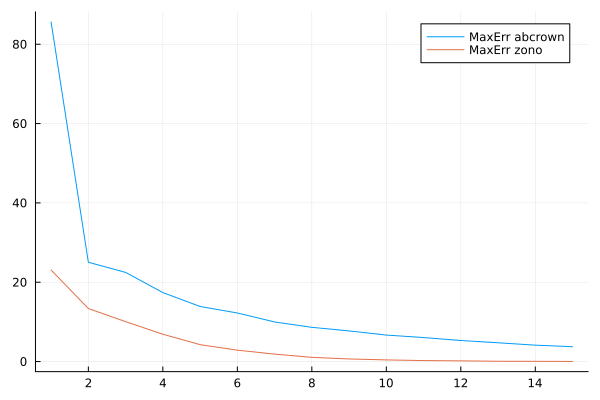

In [9]:
plot(degrees, result_dict["gelu_1e4_abcrown"].max_errs, label="MaxErr abcrown")
plot!(degrees, result_dict["gelu_1e4_zono"].max_errs, label="MaxErr zono")

### ReLU

In [10]:
onnx_path = "../networks/mnist/mnist_256x4_1e4.onnx"

"../networks/mnist/mnist_256x4_1e4.onnx"

In [11]:
mode = :abcrown
max_errs, maes, mses, accs = compute_approximation_stats(onnx_path, degrees; max_polys_per_layer=max_polys_per_layer, max_iter=max_iter, mode=mode)
result_dict["relu_1e4_abcrown"] = (max_errs=max_errs, maes=maes, mses=mses, accs=accs)

Original accuracy: 0.9864166666666667


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Degree 1: max err = 125.51943594874413, mae = 114.49785127462329, mse = 59034.335563450295, acc = 0.10441666666666667


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Degree 2: max err = 29.796197139115204, mae = 20.175773902708595, mse = 1343.143778634591, acc = 0.14685


...

Degree 14: max err = 4.712275761681742, mae = 2.0695276973575263, mse = 12.911145752651706, acc = 0.9825666666666667


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Degree 15: max err = 4.251635618947201, mae = 1.7982353474587882, mse = 9.9563441733462, acc = 0.98305


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


(max_errs = Any[125.51943594874413, 29.796197139115204, 19.582007322074997, 14.569400735057938, 12.151954297467636, 10.582886038723625, 9.148457638545242, 8.576016012801452, 7.291224979783772, 6.432471380932601, 5.9358713660758635, 5.554038363118343, 5.108343667344774, 4.712275761681742, 4.251635618947201], maes = Any[114.49785127462329, 20.175773902708595, 12.806602257694243, 9.710993144117742, 8.025218392377102, 6.918936571917745, 5.902049848188483, 5.0946884772882495, 4.391610351887061, 3.767523621658484, 3.2217811235890306, 2.81574496461951, 2.3888340480019337, 2.0695276973575263, 1.7982353474587882], mses = Any[59034.335563450295, 1343.143778634591, 364.7886623987944, 172.49663932782207, 122.23314409088809, 98.13970511075358, 78.53300072587626, 62.9666632507918, 49.059099850670776, 37.93572842476084, 28.664763155050785, 22.6739409049651, 16.798721759168412, 12.911145752651706, 9.9563441733462], accs = Any[0.10441666666666667, 0.14685, 0.4444666666666667, 0.7643666666666666, 0.9085

In [12]:
mode = :zono
max_errs, maes, mses, accs = compute_approximation_stats(onnx_path, degrees; max_polys_per_layer=max_polys_per_layer, max_iter=max_iter, mode=mode)
result_dict["relu_1e4_zono"] = (max_errs=max_errs, maes=maes, mses=mses, accs=accs)

Original accuracy: 0.9864166666666667


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Degree 1: max err = 26.006384459084522, mae = 14.42347746284934, mse = 624.1409951488691, acc = 0.26708333333333334
Degree 2: max err = 12.576386480766903, mae = 5.878395580041952, mse = 101.89405313240236, acc = 0.8701
Degree 3: max err = 9.301873063757736, mae = 3.9316811831698812, mse = 53.62934962330042, acc = 0.9553833333333334
Degree 4: max err = 6.275449517017796, mae = 2.3599168366433747, mse = 19.324914820831236, acc = 0.9701
Degree 5: max err = 4.753547672822248, mae = 1.4509767289278428, mse = 7.134287764670054, acc = 0.9777166666666667
Degree 6: max err = 4.63762619209853, mae = 1.1962367720105103, mse = 4.784406776910042, acc = 0.9796166666666667
Degree 7: max err = 3.6988367681472467, mae = 0.9641866854484706, mse = 3.1358399584287597, acc = 0.98215
Degree 8: max err = 3.3383496385180926, mae = 0.8206459433279436, mse = 2.307975129515132, acc = 0.98355
Degree 9: max err = 2.7163053791842806, mae = 0.736267101796063, mse = 1.8596510483443403, acc = 0.9844166666666667
Degre

(max_errs = Any[26.006384459084522, 12.576386480766903, 9.301873063757736, 6.275449517017796, 4.753547672822248, 4.63762619209853, 3.6988367681472467, 3.3383496385180926, 2.7163053791842806, 2.7422362290539164, 2.702975314627121, 2.103672167462455, 1.7071937175938467, 1.5601111436680482, 1.4003929049431783], maes = Any[14.42347746284934, 5.878395580041952, 3.9316811831698812, 2.3599168366433747, 1.4509767289278428, 1.1962367720105103, 0.9641866854484706, 0.8206459433279436, 0.736267101796063, 0.6257171859605669, 0.5670364407785947, 0.5074737950101663, 0.46129108927879703, 0.4215914698208304, 0.38927332905277134], mses = Any[624.1409951488691, 101.89405313240236, 53.62934962330042, 19.324914820831236, 7.134287764670054, 4.784406776910042, 3.1358399584287597, 2.307975129515132, 1.8596510483443403, 1.3564234562943136, 1.1107980209720631, 0.8912227391205518, 0.7282399458170942, 0.6040245462580636, 0.5153357235786028], accs = Any[0.26708333333333334, 0.8701, 0.9553833333333334, 0.9701, 0.97

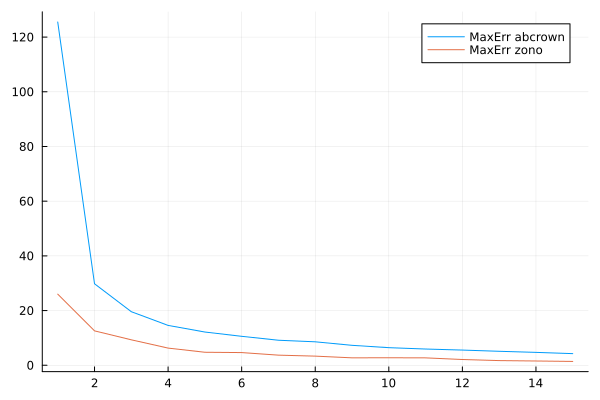

In [13]:
plot(degrees, result_dict["relu_1e4_abcrown"].max_errs, label="MaxErr abcrown")
plot!(degrees, result_dict["relu_1e4_zono"].max_errs, label="MaxErr zono")